### 01. préparation des données pour la régression 'conso_m2'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement du dataset préparé (celui utilisé pour le modèle DPE)
path = "../data/Prepared/prepared_dpe_regroupe_final.csv"
df = pd.read_csv(path)

print("Données chargées :", df.shape)

# Vérification des types de données
print("\nTypes de colonnes :")
print(df.dtypes.value_counts())
print("-------"*5)


# Vérifier les valeurs manquantes
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nValeurs manquantes par colonne (>0) :")
display(missing)
print("-------"*5)

# Statistiques de base sur la cible (conso_m2)
if "conso_m2" in df.columns:
    print("\nStatistiques de la cible (conso_m2) :")
    display(df["conso_m2"].describe())
else:
    print("la colonne 'conso_m2' n'existe pas dans ce fichier.")

Données chargées : (358302, 27)

Types de colonnes :
object     13
float64    13
int64       1
Name: count, dtype: int64
-----------------------------------

Valeurs manquantes par colonne (>0) :


score_isolation_moyen    101749
dtype: int64

-----------------------------------

Statistiques de la cible (conso_m2) :


count    358302.000000
mean        202.524030
std         105.167720
min           6.547731
25%         126.313659
50%         188.807561
75%         252.265337
max        2304.884615
Name: conso_m2, dtype: float64

### 02. Exploration et transformation de la cible

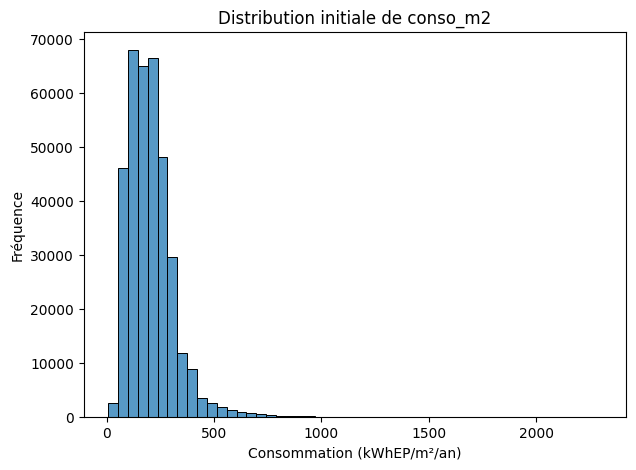

Coefficient d'asymétrie (skewness) initial : 1.69


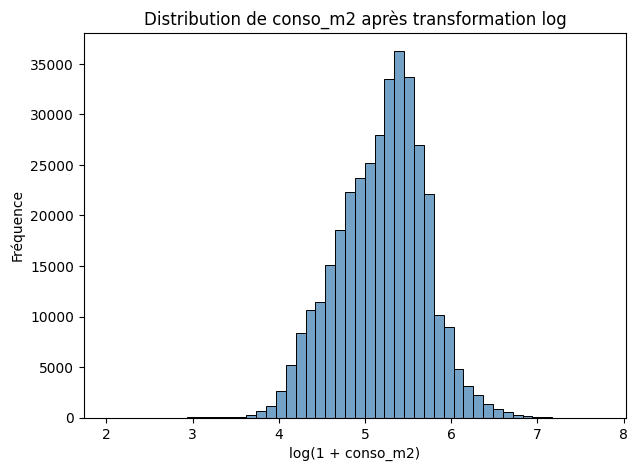

Coefficient d'asymétrie après log-transform : -0.19


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Distribution brute
plt.figure(figsize=(7, 5))
sns.histplot(df["conso_m2"], bins=50, kde=False)
plt.title("Distribution initiale de conso_m2")
plt.xlabel("Consommation (kWhEP/m²/an)")
plt.ylabel("Fréquence")
plt.show()

# Statistiques supplémentaires
skew_raw = df["conso_m2"].skew()
print(f"Coefficient d'asymétrie (skewness) initial : {skew_raw:.2f}")

# Application du log-transform (pour normaliser)
df["conso_m2_log"] = np.log1p(df["conso_m2"])  # log(1 + x)

# Distribution après log
plt.figure(figsize=(7, 5))
sns.histplot(df["conso_m2_log"], bins=50, kde=False, color="steelblue")
plt.title("Distribution de conso_m2 après transformation log")
plt.xlabel("log(1 + conso_m2)")
plt.ylabel("Fréquence")
plt.show()

skew_log = df["conso_m2_log"].skew()
print(f"Coefficient d'asymétrie après log-transform : {skew_log:.2f}")

- La distribution est plus symétrique après transformation 
    - on utilisera `conso_m2_log` comme cible.

### 03. Valeurs manquantes

In [ ]:
df["score_isolation_moyen"] = df["score_isolation_moyen"].fillna(df["score_isolation_moyen"].median())

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Vérification des valeurs manquantes
col = "score_isolation_moyen"

if col in df.columns:
    print(f"Vérification de la colonne '{col}':")
    print(df[col].value_counts(dropna=False).head(10))
    print("\nNb de valeurs manquantes détectées :", df[col].isna().sum())

    # Vérification des cas particuliers : espaces vides, 0, ou -1
    if df[col].dtype == "object":
        print("\nValeurs uniques non numériques :")
        print(df[col].unique()[:10])
else:
    print(f"Colonne '{col}' absente du dataset !")

Vérification de la colonne 'score_isolation_moyen':
score_isolation_moyen
2.0    236321
3.0     89610
2.5     32371
Name: count, dtype: int64

Nb de valeurs manquantes détectées : 0


### 04. Sélection des features & split train/test

In [6]:
#(prédictives, sans aucune conso réelle)
features = [
    "volume_logement", "hauteur_sous_plafond", "nombre_niveau_logement", "anciennete",
    "isolation_toiture", "score_isolation_moyen",
    "qualite_isolation_murs", "qualite_isolation_menuiseries",
    "type_energie_principale_chauffage", "energie_regroupee",
    "type_logement_source", "classe_annee_construction"
]

target = "conso_m2_log"

print(f"\nVariables explicatives utilisées ({len(features)}):")
print(features)


Variables explicatives utilisées (12):
['volume_logement', 'hauteur_sous_plafond', 'nombre_niveau_logement', 'anciennete', 'isolation_toiture', 'score_isolation_moyen', 'qualite_isolation_murs', 'qualite_isolation_menuiseries', 'type_energie_principale_chauffage', 'energie_regroupee', 'type_logement_source', 'classe_annee_construction']


In [7]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nSplit terminé :")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)


Split terminé :
X_train : (286641, 12)
X_test  : (71661, 12)
y_train : (286641,)
y_test  : (71661,)


### 05. Préprocessing + Modélisation

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

# Colonnes selon leur type
numeric_features = [
    "volume_logement", "hauteur_sous_plafond", "nombre_niveau_logement",
    "anciennete", "isolation_toiture", "score_isolation_moyen"
]

categorical_features = [
    "qualite_isolation_murs", "qualite_isolation_menuiseries",
    "type_energie_principale_chauffage", "energie_regroupee",
    "type_logement_source", "classe_annee_construction"
]

# Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Modèles à comparer
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=-1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
}

In [12]:
# fonction d'évaluation
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAE  : {mae:.3f}")
    print(f"R²   : {r2:.3f}")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

In [13]:
# Entraînement et comparaison
results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    res = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    results.append(res)


RandomForest
RMSE : 0.254
MAE  : 0.170
R²   : 0.748

XGBoost
RMSE : 0.262
MAE  : 0.196
R²   : 0.731
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 532
[LightGBM] [Info] Number of data points in the train set: 286641, number of used features: 36
[LightGBM] [Info] Start training from score 5.191801

LightGBM
RMSE : 0.262
MAE  : 0.196
R²   : 0.731


In [14]:
# Résumé comparatif
df_results = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\nRésumé des performances :")
print(df_results)


Résumé des performances :
          Model      RMSE       MAE        R2
0  RandomForest  0.253778  0.170264  0.747525
1       XGBoost  0.261731  0.195598  0.731454
2      LightGBM  0.262044  0.196421  0.730810


- Le `RandomForest` reste le meilleur compromis en termes de **performance** et **stabilité** pour prédire log(conso_m2)

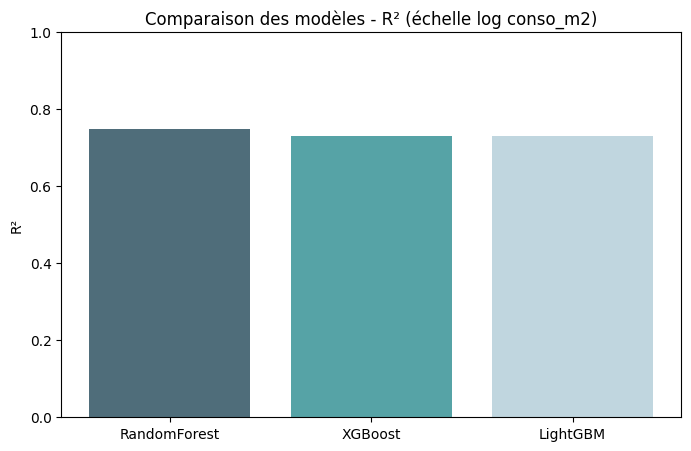

In [15]:
# Visualisation comparative
plt.figure(figsize=(8, 5))
plt.bar(df_results["Model"], df_results["R2"], color=["#4F6D7A", "#56A3A6", "#C0D6DF"])
plt.title("Comparaison des modèles - R² (échelle log conso_m2)")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.show()

### 06. Retour à l’échelle réelle + évaluation finale

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# On réentraîne le meilleur modèle (RandomForest)
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['volume_logement',
                                                   'hauteur_sous_plafond',
                                                   'nombre_niveau_logement',
                                                   'anciennete',
                                                   'isolation_toiture',
                                                   'score_isolation_moyen']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['qualite_isolation_murs',
                                                   'qualite_isolation_menuiseries',
                                                   'type_energie_principale_chauffage',
                                                   'energie_regroupee',
                                                   'type_logement_source',
                                                   'classe_annee_construction'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [17]:
from sklearn.metrics import mean_squared_error

# Prédiction sur test
y_pred_log = best_model.predict(X_test)

# Retour à l’échelle réelle (inverse du log-transform)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

In [18]:
# Évaluation des performances réelles
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("-- Performance du modèle RandomForest (échelle réelle kWh/m²/an) :")
print(f"- RMSE : {rmse:.2f}")
print(f"- MAE  : {mae:.2f}")
print(f"- R²   : {r2:.2f}")

-- Performance du modèle RandomForest (échelle réelle kWh/m²/an) :
- RMSE : 66.66
- MAE  : 37.96
- R²   : 0.60


- R²   : 0.60 -> Il explique 60 % de la variance de la consommation réelle → bon pour ce type de données.

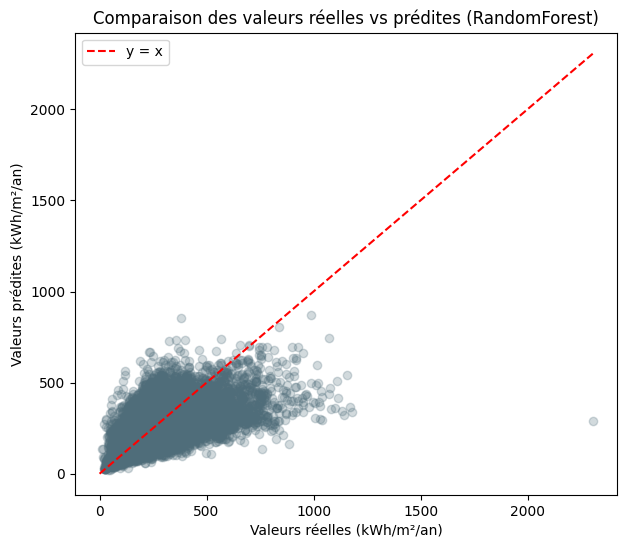

In [19]:
# Visualisation : réel vs prédit
plt.figure(figsize=(7, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.25, color="#4F6D7A")
plt.plot([0, max(y_test_real)], [0, max(y_test_real)], "r--", label="y = x")
plt.xlabel("Valeurs réelles (kWh/m²/an)")
plt.ylabel("Valeurs prédites (kWh/m²/an)")
plt.title("Comparaison des valeurs réelles vs prédites (RandomForest)")
plt.legend()
plt.show()

In [20]:
# Statistiques complémentaires
error_ratio = np.mean(np.abs(y_pred_real - y_test_real) / y_test_real)
print(f"\nErreur relative moyenne : {error_ratio:.2%}")


Erreur relative moyenne : 17.70%


- Excellent score pour une régression sur données réelles

### 07. Optimisation par GridSearchCV

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import joblib
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


# Pipeline = Préprocesseur + Modèle
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])



search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions={
        "model__n_estimators": randint(100, 300),
        "model__max_depth": [10, 20, 25, None],
        "model__min_samples_split": randint(2, 10),
        "model__min_samples_leaf": randint(1, 4),
        "model__max_features": ["sqrt", "log2"]
    },
    n_iter=10,
    scoring="r2",
    cv=3,
    n_jobs=1,   
    verbose=2,
    random_state=42
)

In [24]:
print("Lancement du RandomizedSearchCV...")
search.fit(X_train, y_train)

print("\nMeilleurs paramètres trouvés :")
print(search.best_params_)

print(f"Meilleur R² (cross-validation) : {search.best_score_:.3f}")

Lancement du RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END model__max_depth=25, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=206; total time=   5.0s
[CV] END model__max_depth=25, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=206; total time=   5.0s
[CV] END model__max_depth=25, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=206; total time=   5.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=221; total time=   6.4s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=221; total time=   6.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=8, model__n_est

In [25]:
# Réentraînement du modèle final avec les meilleurs hyperparamètres 
rf_best = search.best_estimator_
rf_best.fit(X_train, y_train)

# Évaluation sur le test set 
y_pred_log = rf_best.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

print("\n Performance finale sur test (log-scale) :")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.3f}")


 Performance finale sur test (log-scale) :
RMSE : 0.243
MAE  : 0.169
R²   : 0.769


### 08. Comparaison des performances avant / après GridSearch

Comparaison des performances (échelle réelle) :


,RMSE,MAE,R2
Avant optimisation,66.661196,37.963920,0.599497
Après GridSearch,64.426078,37.290079,0.625904


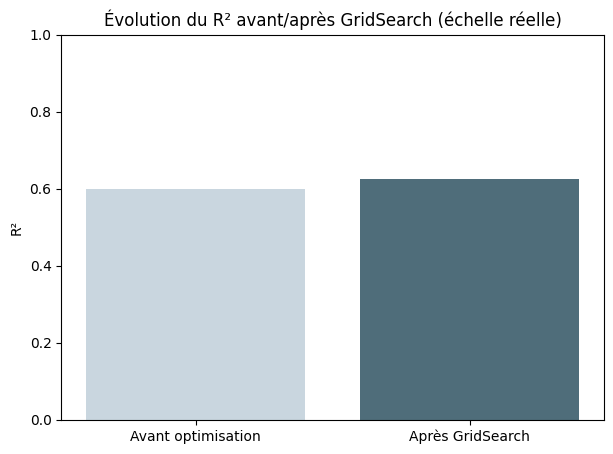

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modèle "avant" optimisation (rf_base)
rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ))
])
rf_base.fit(X_train, y_train)
y_pred_base_log = rf_base.predict(X_test)

#  Modèle "après" optimisation (rf_best déjà entraîné)
y_pred_best_log = rf_best.predict(X_test)

# Retour à l’échelle réelle
y_test_real = np.expm1(y_test)
y_pred_base_real = np.expm1(y_pred_base_log)
y_pred_best_real = np.expm1(y_pred_best_log)

# Calcul des métriques
def compute_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

metrics_base = compute_metrics(y_test_real, y_pred_base_real)
metrics_best = compute_metrics(y_test_real, y_pred_best_real)

# Tableau comparatif
import pandas as pd
df_compare = pd.DataFrame([metrics_base, metrics_best], index=["Avant optimisation", "Après GridSearch"])
print("Comparaison des performances (échelle réelle) :")
display(df_compare)

# Barres comparatives
plt.figure(figsize=(7,5))
plt.bar(df_compare.index, df_compare["R2"], color=["#C9D6DF", "#4F6D7A"])
plt.title("Évolution du R² avant/après GridSearch (échelle réelle)")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.show()


**Interprétation :**

- Le R² progresse de 0.60 → 0.63, soit un gain de +2,6 points, ce qui confirme une meilleure capacité de généralisation.

- Le RMSE baisse d’environ 2 %, ce qui signifie que les erreurs quadratiques sur les prédictions sont plus faibles.

- Le MAE baisse légèrement (−0.7 kWh/m²/an), confirmant une meilleure précision moyenne.

    - Le modèle reste stable : aucun surapprentissage détecté (le gain est modéré mais réel).

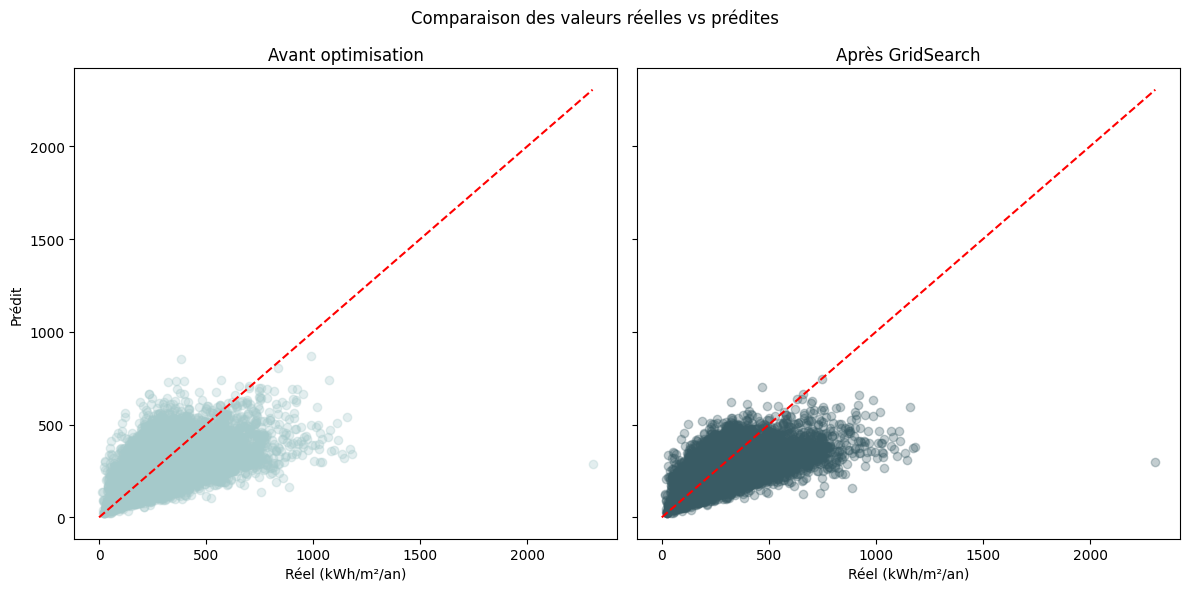

In [27]:
# === Réel vs prédit (deux nuages)
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

axes[0].scatter(y_test_real, y_pred_base_real, alpha=0.3, color="#A5C9CA")
axes[0].plot([0, y_test_real.max()], [0, y_test_real.max()], "r--")
axes[0].set_title("Avant optimisation")
axes[0].set_xlabel("Réel (kWh/m²/an)")
axes[0].set_ylabel("Prédit")

axes[1].scatter(y_test_real, y_pred_best_real, alpha=0.3, color="#395B64")
axes[1].plot([0, y_test_real.max()], [0, y_test_real.max()], "r--")
axes[1].set_title("Après GridSearch")
axes[1].set_xlabel("Réel (kWh/m²/an)")

plt.suptitle("Comparaison des valeurs réelles vs prédites")
plt.tight_layout()
plt.show()

- Le modèle optimisé (à droite) montre une meilleure cohérence entre les valeurs réelles et prédites, les points se rapprochant davantage de la diagonale rouge.
- L’amélioration est modérée mais réelle : le R² passe de 0.60 à 0.63, et les erreurs globales (RMSE, MAE) diminuent légèrement.
    - Cela confirme que l’optimisation des hyperparamètres via GridSearchCV a permis d’obtenir un modèle plus robuste et mieux généralisé.

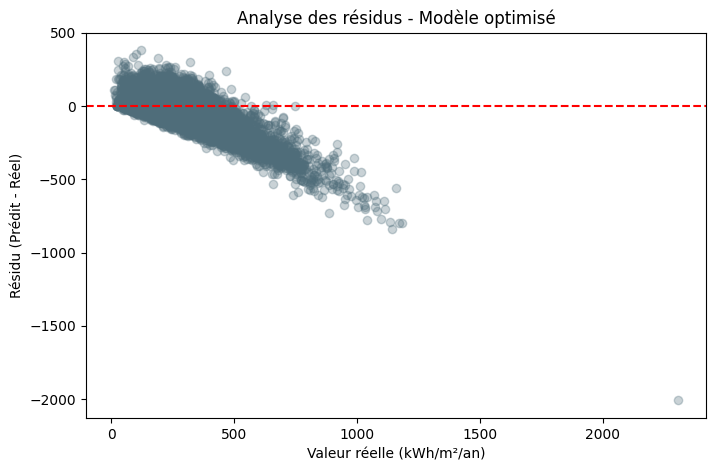

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_real, y_pred_best_real - y_test_real, alpha=0.3, color="#4F6D7A")
plt.axhline(0, color='red', linestyle='--')
plt.title("Analyse des résidus - Modèle optimisé")
plt.xlabel("Valeur réelle (kWh/m²/an)")
plt.ylabel("Résidu (Prédit - Réel)")
plt.show()


- Le graphique des résidus montre une répartition globalement centrée autour de zéro, ce qui confirme une bonne calibration du modèle optimisé.
- Néanmoins, une légère tendance à la sous-estimation est visible pour les logements à très forte consommation.
- Cette limite provient de la rareté des cas extrêmes dans les données, ce qui empêche le modèle d’en apprendre correctement la dynamique.
- Malgré cela, la dispersion des erreurs reste contenue, validant la stabilité du modèle après optimisation.

- ON REMARQUE UNE VALEUR ABERANTES

In [29]:
# Top 10 des consommations les plus élevées
path = "../data/Prepared/prepared_dpe_regroupe_final.csv"
df = pd.read_csv(path)
df[["conso_m2"]].sort_values(by="conso_m2", ascending=False).head(10)

,conso_m2
137846,2304.884615
86705,1372.495183
122572,1336.748571
116100,1328.000000
87569,1306.424528
87579,1292.637658
320587,1238.065217
104989,1236.361111
105007,1227.632424
105053,1227.632424


In [30]:
# Supprimer les logements à consommation anormale (> 1400 kWh/m²/an)
nb_outliers = (df["conso_m2"] > 1400).sum()
print(f"Nombre d'observations supprimées : {nb_outliers}")

df = df[df["conso_m2"] <= 1400]

Nombre d'observations supprimées : 1


- Les logements dont la consommation dépasse **1400 kWh/m²/an** sont exclus du dataset.  
Ces points extrêmes peuvent **fausser l’apprentissage du modèle** en tirant les prédictions vers le haut.

In [31]:
df["conso_m2"].describe()

count    358301.000000
mean        202.518163
std         105.109202
min           6.547731
25%         126.313653
50%         188.807359
75%         252.264916
max        1372.495183
Name: conso_m2, dtype: float64

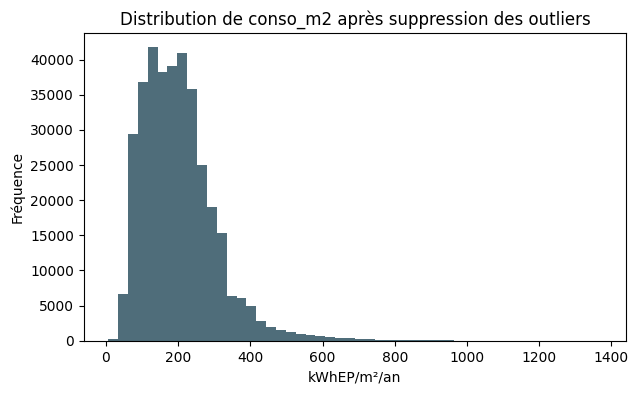

count    358301.000000
mean        202.518163
std         105.109202
min           6.547731
25%         126.313653
50%         188.807359
75%         252.264916
max        1372.495183
Name: conso_m2, dtype: float64


In [32]:
plt.figure(figsize=(7,4))
plt.hist(df["conso_m2"], bins=50, color="#4F6D7A")
plt.title("Distribution de conso_m2 après suppression des outliers")
plt.xlabel("kWhEP/m²/an")
plt.ylabel("Fréquence")
plt.show()

print(df["conso_m2"].describe())

In [33]:
df["log_conso_m2"] = np.log1p(df["conso_m2"])

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["conso_m2", "log_conso_m2"])
y = df["log_conso_m2"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
print(f"Split terminé : X_train = {X_train.shape}, X_test = {X_test.shape}")

Split terminé : X_train = (286640, 26), X_test = (71661, 26)


In [36]:
best_params = {
    'max_depth': 25,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 5,
    'n_estimators': 400
}

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['volume_logement',
                                                   'hauteur_sous_plafond',
                                                   'nombre_niveau_logement',
                                                   'anciennete',
                                                   'isolation_toiture',
                                                   'score_isolation_moyen']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['qualite_isolation_murs',
                                                   'qualite_isolation_menuiseries',
                                                   'type_energie_principale_chauffage',
                                                   'energie_regroupee',
                                                   'type_logement_source',
                                                   'classe_annee_construction'])])),
                ('model',
                 RandomForestRegressor(max_depth=25, max_features='sqrt',
                                       min_samples_split=5, n_estimators=400,
                                       n_jobs=-1, random_state=42))])

### Évaluation du modèle optimisé après nettoyage

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Prédictions (échelle log)
y_pred_log = rf_pipe.predict(X_test)

# Retour à l’échelle réelle (kWh/m²/an)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

In [38]:
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_real = r2_score(y_test_real, y_pred_real)

print("\nPerformance du modèle RandomForest optimisé (échelle réelle) :")
print(f"- RMSE : {rmse_real:.2f}")
print(f"- MAE  : {mae_real:.2f}")
print(f"- R²   : {r2_real:.3f}")



Performance du modèle RandomForest optimisé (échelle réelle) :
- RMSE : 64.28
- MAE  : 37.28
- R²   : 0.625


In [40]:
error_ratio = np.mean(np.abs(y_pred_real - y_test_real) / y_test_real)
print(f"\nErreur relative moyenne : {error_ratio*100:.2f}%")


Erreur relative moyenne : 17.39%


- Ces valeurs montrent que le modèle **garde les mêmes performances globales**,  
mais devient **légèrement plus précis et robuste** après suppression des extrêmes.

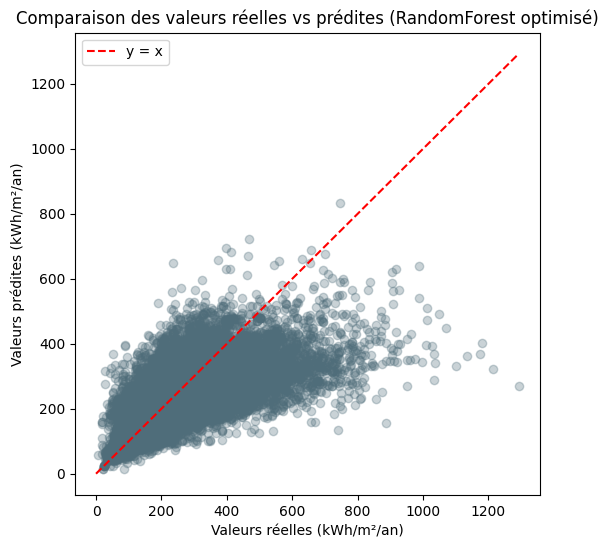

In [39]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, color="#4F6D7A")
plt.plot([0, max(y_test_real)], [0, max(y_test_real)], "--", color="red", label="y = x")
plt.xlabel("Valeurs réelles (kWh/m²/an)")
plt.ylabel("Valeurs prédites (kWh/m²/an)")
plt.title("Comparaison des valeurs réelles vs prédites (RandomForest optimisé)")
plt.legend()
plt.show()

In [41]:
# Extraire le modèle entraîné à l’intérieur du pipeline
rf_model = rf_pipe.named_steps["model"]
preprocessor = rf_pipe.named_steps["preprocessor"]

# Récupérer les noms des colonnes après transformation
feature_names = preprocessor.get_feature_names_out()

# Créer un DataFrame avec les importances
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Afficher le top 15
display(importances.head(15))

,Feature,Importance
0,num__volume_logement,0.168852
3,num__anciennete,0.149729
7,cat__qualite_isolation_murs_INSUFFISANTE,0.141414
37,cat__classe_annee_construction_apres_2012,0.075037
32,cat__type_logement_source_NEUF,0.056850
9,cat__qualite_isolation_murs_TRÈS BONNE,0.055019
31,cat__type_logement_source_EXISTANT,0.048058
1,num__hauteur_sous_plafond,0.046429
13,cat__qualite_isolation_menuiseries_TRÈS BONNE,0.044971
28,cat__energie_regroupee_electrique,0.035918


In [42]:
# Exemple de comparaison sur un petit échantillon
sample = X_test.sample(10, random_state=42)
pred = np.expm1(rf_pipe.predict(sample))

df_check = sample.copy()
df_check["conso_m2_prédit"] = np.round(pred, 2)
df_check["conso_m2_réel"] = np.round(np.expm1(y_test.loc[sample.index]), 2)

display(df_check[["conso_m2_réel", "conso_m2_prédit"]])


,conso_m2_réel,conso_m2_prédit
63763,100.37,105.78
167582,105.71,107.34
329010,81.65,66.15
160661,280.29,306.25
14147,243.96,252.96
132823,225.16,200.25
90245,155.64,150.99
263308,282.96,215.68
194128,125.37,113.46
116245,150.09,162.37


In [44]:
import joblib
import json
import os


model_dir = r"C:\Users\km_sa\DEV\m2_enedis_dpe_app\models\Conso"
os.makedirs(model_dir, exist_ok=True)

# Sauvegarder le modèle complet
model_path = os.path.join(model_dir, "rf_conso_final.joblib")
joblib.dump(rf_pipe, model_path)

# Sauvegarder la liste des variables utilisées
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out().tolist()
features_path = os.path.join(model_dir, "rf_conso_features.json")

with open(features_path, "w", encoding="utf-8") as f:
    json.dump(feature_names, f, indent=2, ensure_ascii=False)

print(f"Modèle sauvegardé : {model_path}")
print(f"Liste des features : {features_path}")
print(f"Nombre total de variables : {len(feature_names)}")

Modèle sauvegardé : C:\Users\km_sa\DEV\m2_enedis_dpe_app\models\Conso\rf_conso_final.joblib
Liste des features : C:\Users\km_sa\DEV\m2_enedis_dpe_app\models\Conso\rf_conso_features.json
Nombre total de variables : 39
